IT Service Ticket Classification Dataset: https://www.kaggle.com/datasets/adisongoh/it-service-ticket-classification-dataset


In [ ]:
# Step 1: Import the tools we need
import pandas as pd
from sklearn.naive_bayes import MultinomialNB       # The Naive Bayes model
from sklearn.feature_extraction.text import CountVectorizer  # Turns words into numbers
from sklearn.model_selection import train_test_split  # Split data into train/test
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # Check how well the model did
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# load dataset
df = pd.read_csv("all_tickets_processed_improved_v3.csv")
df.head()

,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


In [ ]:
# dataset overview
df.info()
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47837 entries, 0 to 47836
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Document     47837 non-null  object
 1   Topic_group  47837 non-null  object
dtypes: object(2)
memory usage: 747.6+ KB
(47837, 2)


In [ ]:
# check for duplicated rows
df.duplicated(subset=["Document", "Topic_group"]).sum()

np.int64(0)

In [ ]:
# view output label distribution
print(df['Topic_group'].value_counts())

Topic_group
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760
Name: count, dtype: int64


In [ ]:
# define the X features and y (output label)
X = df["Document"]  # Input features
y = df["Topic_group"]                 # Output label

In [ ]:
# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing
    random_state=42,   # Same split every run (reproducible)
    stratify =y      # Keeps class distribution the same in train and test sets
)

In [ ]:
# Convert text data into numerical feature vectors using word counts
vectorizer = CountVectorizer()   # Create the converter tool
X_train_vec = vectorizer.fit_transform(X_train)   # learn vocabulary and transform training data
X_test_vec = vectorizer.transform(X_test)


In [ ]:
# Train on MultinomialNB
model = MultinomialNB()    # Create a blank (untrained) model
model.fit(X_train_vec, y_train)


MultinomialNB()

In [ ]:
# Predict
y_predicted = model.predict(X_test_vec)

# Evaluate
accuracy = accuracy_score(y_test, y_predicted)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Classification Report for model
print("\nClassification Report:\n", classification_report(y_test, y_predicted))   # display metrics to evaluate model

Accuracy: 76.92%

Classification Report:
                        precision    recall  f1-score   support

               Access       0.72      0.84      0.78      1425
Administrative rights       0.63      0.68      0.65       352
           HR Support       0.85      0.72      0.78      2183
             Hardware       0.81      0.75      0.78      2724
     Internal Project       0.67      0.79      0.73       424
        Miscellaneous       0.72      0.75      0.73      1412
             Purchase       0.89      0.87      0.88       493
              Storage       0.70      0.88      0.78       555

             accuracy                           0.77      9568
            macro avg       0.75      0.78      0.76      9568
         weighted avg       0.78      0.77      0.77      9568



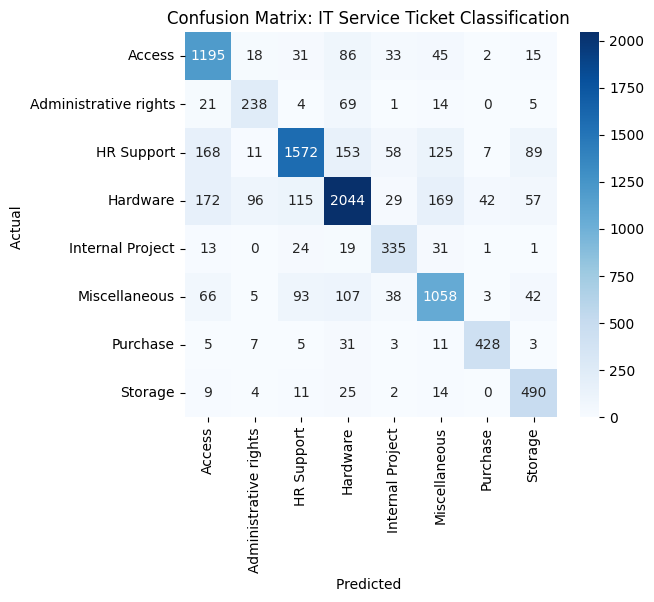

In [ ]:
# Confusion matrix  -- see how IT Service Ticket Classification are being predicted vs actual
cm = confusion_matrix(y_test, y_predicted)

# define class labels for plot
labels = model.classes_

# Visualize the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels= labels, yticklabels=labels)
plt.xlabel('Predicted ')
plt.ylabel('Actual ')
plt.title('Confusion Matrix: IT Service Ticket Classification ')
plt.show()

In [ ]:
# Test the model on new IT support tickets

#  new IT support tickets
test_tickets = [
    "My internet connection is very slow and keeps disconnecting",
    "I cannot log into my account, it says password is incorrect",
    "The app crashes every time I try to open it",
    "The computer will not turn on"
]

# Convert the new IT tickets into numbers using the SAME vectorizer
X_new = vectorizer.transform(test_tickets)  # Use transform() only, already learned using fit

# Ask the model to make predictions
predictions = model.predict(X_new)

# Get the probability of each prediction
probabilities = model.predict_proba(X_new)


# Print the prediction and probabilities for each test ticket
for i, text in enumerate(test_tickets):

    predicted_class = predictions[i]
    print(f"Ticket: {text}")
    print(f" --> Predicted category: {predicted_class}")

    # print probabilities for each possible class
    print(" --> Probabilities:")
    for j, label in enumerate(model.classes_):
        prob = probabilities[i][j] * 100
        print(f"     {label}: {prob:.1f}%")

    print()

Ticket: My internet connection is very slow and keeps disconnecting
 --> Predicted category: Hardware
 --> Probabilities:
     Access: 0.0%
     Administrative rights: 28.2%
     HR Support: 0.0%
     Hardware: 71.8%
     Internal Project: 0.0%
     Miscellaneous: 0.0%
     Purchase: 0.0%
     Storage: 0.0%

Ticket: I cannot log into my account, it says password is incorrect
 --> Predicted category: Access
 --> Probabilities:
     Access: 93.2%
     Administrative rights: 1.1%
     HR Support: 0.0%
     Hardware: 5.5%
     Internal Project: 0.0%
     Miscellaneous: 0.1%
     Purchase: 0.0%
     Storage: 0.0%

Ticket: The app crashes every time I try to open it
 --> Predicted category: Hardware
 --> Probabilities:
     Access: 0.3%
     Administrative rights: 12.7%
     HR Support: 23.5%
     Hardware: 58.0%
     Internal Project: 0.0%
     Miscellaneous: 5.0%
     Purchase: 0.0%
     Storage: 0.5%

Ticket: The computer will not turn on
 --> Predicted category: Hardware
 --> Probabiliti

The IT Service Ticket Classification Dataset contained ticket text content with each labeled with a topic group it belongs to. There were 8 possible groups: 'Hardware', 'HR Support', 'Access', 'Miscellaneous', 'Storage', 'Purchase', 'Internal Project', 'Administrative rights.' The MultinomialNB was used to categorize and analyze the text content of tickets. This model shows how multinomialNB can be useful in categorizing and defining text based content into useful parameters and indicators. First, the data was prepped to ensure there were no duplicated or null values. Once the data was split into testing and training, both input text for both sets was converted into numbers. Converting each  ticket text into a number lists. Then the model is trained, and the test set used to predict the model. The model had a 76.92% accuracy. The individual class performance metrics showed varying performances, some classes being better predicted and identified than others. The confusion matrix shows how the topic groups overlap and are identified as other groups vs actual. No group is perfect, some groups seem more distinctive compared to others. Altogether, classification report metrics and confusion metrics reflect the overall average performance model.   
